## Decision Tree — Product Category Routing for E-Commerce Returns
 
### Business Problem
 
An e-commerce operations team processes thousands of product returns daily. Returns arrive with a text description and product metadata, and they need to be routed to the correct handling team (refurbishment, recycling, restocking, or disposal). Manual routing is slow and inconsistent. A decision tree can learn the routing logic and apply it instantly at scale.
 
### Why a Decision Tree?
 
Decision trees are ideal here for two reasons. First, the routing rules are **inherently hierarchical and conditional** ("if category is electronics AND condition is damaged, route to recycling") — exactly the kind of logic a decision tree learns naturally. Second, the operations team needs to **audit and override** the model's decisions; a printed decision tree can be handed to a floor manager who can verify and challenge specific branches. No other model offers this level of direct explainability. Additionally, decision trees require no feature scaling, handle mixed feature types cleanly, and train in milliseconds on this data volume.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

=== Decision Tree: Returns Routing ===
              precision    recall  f1-score   support

     Restock       0.94      0.95      0.94        79
   Refurbish       0.87      0.87      0.87        30
     Recycle       0.90      0.88      0.89        41
     Dispose       0.90      0.90      0.90        50

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.91      0.91      0.91       200

Decision Tree Rules (sharable with operations team):
|--- condition_code <= 1.50
|   |--- original_price_usd <= 148.25
|   |   |--- days_since_purchase <= 72.00
|   |   |   |--- class: 0
|   |   |--- days_since_purchase >  72.00
|   |   |   |--- days_since_purchase <= 303.50
|   |   |   |   |--- class: 0
|   |   |   |--- days_since_purchase >  303.50
|   |   |   |   |--- class: 0
|   |--- original_price_usd >  148.25
|   |   |--- days_since_purchase <= 241.50
|   |   |   |--- days_since_purchase <= 108.50
|   |   |   |  

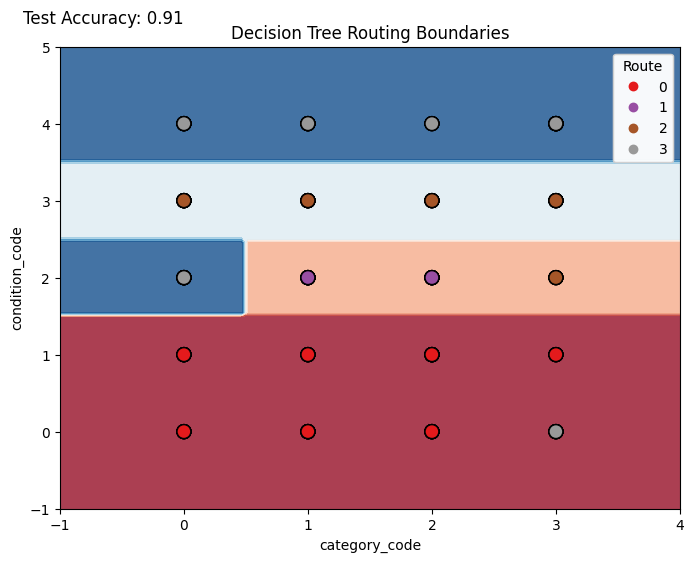

In [2]:
"""
Product return routing using Decision Tree Classifier.
 
Business goal: Automatically route e-commerce returns to the correct
handling team (restocking, refurbishment, recycling, or disposal)
to reduce manual processing time and routing errors.
"""


ROUTE_LABELS = ["Restock", "Refurbish", "Recycle", "Dispose"]
CATEGORY_MAP = {"Electronics": 0, "Clothing": 1, "Furniture": 2, "Toys": 3}
CONDITION_MAP = {"New": 0, "Good": 1, "Fair": 2, "Poor": 3, "Damaged": 4}


def generate_returns_data(n_samples: int = 1_000, seed: int = 42) -> pd.DataFrame:
    """Generate synthetic product returns dataset.

    Args:
        n_samples: Number of return records to generate.
        seed: Random seed for reproducibility.

    Returns:
        DataFrame with encoded product features and routing label.
    """
    rng = np.random.default_rng(seed)

    category_codes = rng.integers(0, len(CATEGORY_MAP), n_samples)
    condition_codes = rng.integers(0, len(CONDITION_MAP), n_samples)
    days_since_purchase = rng.integers(1, 365, n_samples)
    original_price = rng.uniform(5, 500, n_samples)

    route = np.where(
        condition_codes <= 1,
        0,
        np.where(
            (condition_codes == 2) & (category_codes != 0),
            1,
            np.where(condition_codes == 3, 2, 3),
        ),
    )
    noise_mask = rng.random(n_samples) < 0.08
    route[noise_mask] = rng.integers(0, 4, noise_mask.sum())

    return pd.DataFrame(
        {
            "category_code": category_codes,
            "condition_code": condition_codes,
            "days_since_purchase": days_since_purchase,
            "original_price_usd": original_price,
            "route_label": route,
        }
    )


"""Train and evaluate return routing decision tree."""
df = generate_returns_data()
feature_cols = [c for c in df.columns if c != "route_label"]

X = df[feature_cols]
y = df["route_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== Decision Tree: Returns Routing ===")
print(classification_report(y_test, y_pred, target_names=ROUTE_LABELS))

tree_rules = export_text(model, feature_names=feature_cols)
print("Decision Tree Rules (sharable with operations team):")
print(tree_rules)


# Visualize decision boundaries for the first two features
fig, ax = plt.subplots(figsize=(8, 6))
clf = make_pipeline(DecisionTreeClassifier(max_depth=5, random_state=42))
data_two_features = df.loc[:, feature_cols[:2]]
X_train, X_test, y_train, y_test = train_test_split(
    data_two_features, y, test_size=0.2, stratify=y, random_state=42
)
clf.fit(X_train, y_train)
score = clf.score(X_test, y_test)
DecisionBoundaryDisplay.from_estimator(
    clf,
    X_test[feature_cols[:2]],
    response_method="predict",
    ax=ax,
    alpha=0.8,
    cmap="RdBu",
)
scatter = ax.scatter(
    X_test[feature_cols[0]],
    X_test[feature_cols[1]],
    c=y_test,
    edgecolor="k",
    s=100,
    cmap="Set1",
    label="Actual Route",
)
legend1 = ax.legend(*scatter.legend_elements(), title="Route", loc="upper right")
ax.add_artist(legend1)
ax.set_xlabel(feature_cols[0])
ax.set_ylabel(feature_cols[1])
ax.set_title("Decision Tree Routing Boundaries")
x_max, x_min = ax.get_xlim()
y_max, y_min = ax.get_ylim()
ax.text(
    x_max - 0.3,
    y_min + 0.3,
    f"Test Accuracy: {score:.2f}",
    size=12,
    horizontalalignment="left",
)
plt.show()